In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
df = pd.read_csv("data/features_30_sec.csv")
df.describe()
# Will have to scale the data before applying PCA, due to the different ranges of features.

,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,662030.846000,0.378682,0.086340,0.130930,0.003051,2201.780898,4.696916e+05,2242.541070,137079.155165,4571.549304,...,1.148144,60.730958,-3.966028,62.633624,0.507696,63.712586,-2.328761,66.231930,-1.095348,70.126096
std,1784.073992,0.081705,0.007735,0.065683,0.003634,715.960600,4.008995e+05,526.316473,96455.666326,1574.791602,...,4.578948,33.781951,4.549697,33.479172,3.869105,34.401977,3.755957,37.174631,3.837007,45.228512
min,660000.000000,0.171939,0.044555,0.005276,0.000004,570.040355,7.911251e+03,898.066208,10787.185064,749.140636,...,-15.693844,9.169314,-17.234728,13.931521,-11.963694,15.420555,-18.501955,13.487622,-19.929634,7.956583
25%,661504.000000,0.319562,0.082298,0.086657,0.000942,1627.697311,1.843505e+05,1907.240605,67376.554428,3380.069642,...,-1.863280,40.376442,-7.207225,40.830875,-2.007015,41.884240,-4.662925,41.710184,-3.368996,42.372865
50%,661794.000000,0.383148,0.086615,0.122443,0.001816,2209.263090,3.384862e+05,2221.392843,111977.548036,4658.524473,...,1.212809,52.325077,-4.065605,54.717674,0.669643,54.804890,-2.393862,57.423059,-1.166289,59.186117
75%,661794.000000,0.435942,0.091256,0.175682,0.003577,2691.294667,6.121479e+05,2578.469836,182371.576801,5533.810460,...,4.359662,71.691755,-0.838737,75.040838,3.119212,75.385832,0.150573,78.626444,1.312615,85.375374
max,675808.000000,0.663685,0.108111,0.397973,0.027679,4435.243901,3.036843e+06,3509.646417,694784.811549,8677.672688,...,13.457150,392.932373,11.482946,406.058868,15.388390,332.905426,14.694924,393.161987,15.369627,506.065155



Feature loadings (scaled by singular values):
chroma_stft_mean         : PC1 = 11.3570, PC2 = -24.0299, PC3 =  6.0965
chroma_stft_var          : PC1 = -20.8642, PC2 =  4.6921, PC3 =  1.4223
rms_mean                 : PC1 =  1.3623, PC2 = -22.6965, PC3 =  4.7313
rms_var                  : PC1 = -13.7985, PC2 = -17.7565, PC3 =  5.6148
spectral_centroid_mean   : PC1 =  2.0279, PC2 = -26.9222, PC3 =  4.3052
spectral_centroid_var    : PC1 = -18.5681, PC2 = -20.6028, PC3 =  1.8072
spectral_bandwidth_mean  : PC1 = -3.2233, PC2 = -27.3641, PC3 = -0.4535
spectral_bandwidth_var   : PC1 = -18.3394, PC2 = -8.2425, PC3 = -2.7873
rolloff_mean             : PC1 =  1.1645, PC2 = -27.4474, PC3 =  3.4871
rolloff_var              : PC1 = -19.1817, PC2 = -13.4348, PC3 = -1.5184
zero_crossing_rate_mean  : PC1 =  8.1191, PC2 = -19.6835, PC3 =  7.1283
zero_crossing_rate_var   : PC1 = -13.3126, PC2 = -20.9149, PC3 =  5.6741
harmony_mean             : PC1 = -2.5712, PC2 = -2.7049, PC3 = -2.8191
harmony_var   

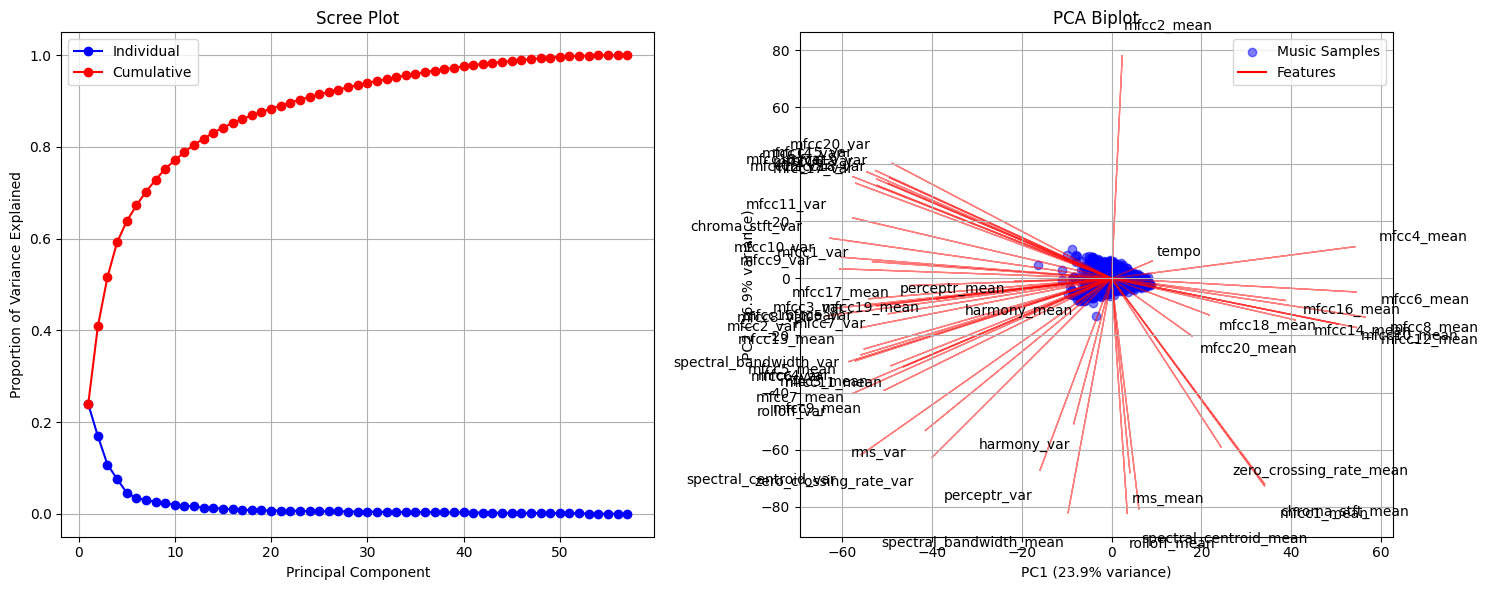

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

X = df.drop(['label', 'filename', 'length'], axis=1)
X_scaled = StandardScaler().fit_transform(X)

# Perform PCA
U, s, Vt = np.linalg.svd(X_scaled)
V = Vt.T

# Create figure with both scree and biplot
fig = plt.figure(figsize=(15, 6))

# 1. Scree plot
plt.subplot(121)
var_exp = s**2 / np.sum(s**2)
cum_var_exp = np.cumsum(var_exp)

plt.plot(range(1, len(var_exp) + 1), var_exp, 'bo-', label='Individual')
plt.plot(range(1, len(cum_var_exp) + 1), cum_var_exp, 'ro-', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.title('Scree Plot')
plt.legend()
plt.grid(True)

# 2. Biplot
plt.subplot(122)
scores = X_scaled @ V
scale = 3  # Adjust this to change relative scaling of arrows

# Plot scores
plt.scatter(scores[:,0], scores[:,1], c='b', alpha=0.5, label='Music Samples')

# Plot loadings
for i, feature in enumerate(X.columns):
    x = V[i,0] * s[0] * scale
    y = V[i,1] * s[1] * scale
    
    plt.arrow(0, 0, x, y, color='r', alpha=0.5, head_width=0.1)
    
    # Add labels with offset based on quadrant
    if x >= 0:
        ha = 'left'
    else:
        ha = 'right'
    if y >= 0:
        va = 'bottom'
    else:
        va = 'top'
        
    plt.text(x*1.1, y*1.1, feature, ha=ha, va=va)

plt.xlabel(f"PC1 ({var_exp[0]:.1%} variance)")
plt.ylabel(f"PC2 ({var_exp[1]:.1%} variance)")
plt.title('PCA Biplot')
plt.grid(True)

# Add legend
plt.plot([0], [0], 'r-', label='Features')
plt.legend()

plt.tight_layout()

# Print feature loadings for reference
print("\nFeature loadings (scaled by singular values):")
for name, v1, v2, v3 in zip(X.columns, 
                       V[:,0] * s[0], 
                       V[:,1] * s[1], 
                       V[:,2] * s[2]):
    print(f"{name:25s}: PC1 = {v1:7.4f}, PC2 = {v2:7.4f}, PC3 = {v3:7.4f}")

In [4]:
import numpy as np
import pandas as pd

# Build a dataframe of loadings
loadings_df = pd.DataFrame({
    'feature': X.columns,
    'PC1': V[:,0] * s[0],
    'PC2': V[:,1] * s[1],
    'PC3': V[:,2] * s[2]
})

# Print top 5 per PC sorted by absolute value descending
for pc in ['PC1', 'PC2', 'PC3']:
    print(f"\nTop 5 features for {pc} (sorted by absolute loading):")
    sorted_pc = loadings_df[['feature', pc]].reindex(
        loadings_df[pc].abs().sort_values(ascending=False).index
    ).head(5)
    print(sorted_pc.to_string(index=False))


Top 5 features for PC1 (sorted by absolute loading):
        feature        PC1
      mfcc2_var -21.086609
chroma_stft_var -20.864182
      mfcc8_var -20.414949
      mfcc9_var -20.165966
     mfcc10_var -20.026032

Top 5 features for PC2 (sorted by absolute loading):
                feature        PC2
           rolloff_mean -27.447418
spectral_bandwidth_mean -27.364129
 spectral_centroid_mean -26.922173
             mfcc2_mean  26.008743
             mfcc1_mean -24.241217

Top 5 features for PC3 (sorted by absolute loading):
    feature       PC3
mfcc10_mean 20.079975
 mfcc8_mean 18.612053
mfcc12_mean 17.701333
mfcc14_mean 16.829293
 mfcc6_mean 16.558615


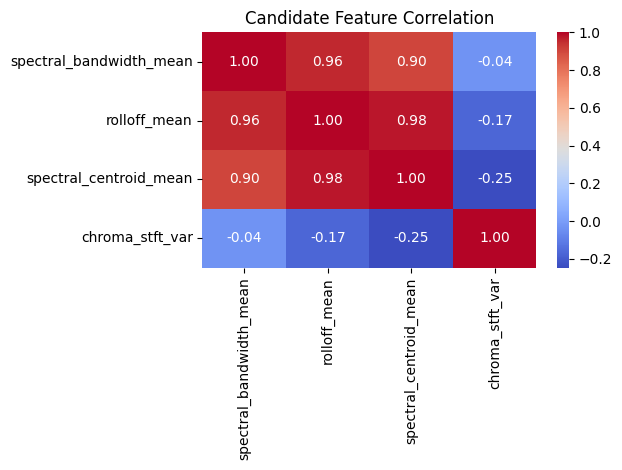

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

candidate_features = [
    'spectral_bandwidth_mean', 'rolloff_mean', 'spectral_centroid_mean',
     'chroma_stft_var']

corr = df[candidate_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Candidate Feature Correlation')
plt.tight_layout()
plt.show()

In [6]:
acoustic = ['classical', 'blues', 'jazz']
rhythmic = ['country', 'reggae', 'rock', 'hiphop']
electric = ['disco', 'pop', 'metal']

def assign_group(label):
    if label in acoustic:
        return 'Acoustic'
    elif label in rhythmic:
        return 'Rhythmic'
    elif label in electric:
        return 'Electric'

df['final_group'] = df['label'].apply(assign_group)

In [ ]:
df.to_csv("data/final_df.csv", index=False)